In [4]:
# Cell 1: Imports
import numpy as np
import importlib
import csv
import os
import matplotlib.pyplot as plt
from pybaselines.whittaker import asls
from scipy.signal import find_peaks
import xrd_functions
from xrd_functions import shift_spectrum_to_peak
importlib.reload(xrd_functions)
%matplotlib widget


In [3]:
# Cell 2: Load XRD data function
def load_XRD_txt(file_path):
    """
    Loads XRD data from a .txt file.
    Assumes two columns: 2theta, intensity.
    """
    data = np.loadtxt(file_path, comments="#", delimiter=None)
    two_theta = data[:, 0]
    intensity = data[:, 1]
    return two_theta, intensity

In [ ]:
# Cell 3: Background subtraction function
def subtract_background(intensity, lam=1e5, p=0.0001):
    """
    Subtracts background using Asymmetric Least Squares (AsLS).
    Returns baseline and background-subtracted intensity.
    """
    baseline = asls(intensity, lam=lam, p=p)[0]
    corrected = intensity - baseline
    return baseline, corrected

In [5]:
# Cell 4: Normalization function
def normalize_to_peak(two_theta, intensity, peak_center=37.9, window=0.2):
    """
    Normalizes intensity to the maximum value within a small window around a given 2θ peak.
    """
    mask = (two_theta > peak_center - window) & (two_theta < peak_center + window)
    peak_intensity = intensity[mask].max()
    normalized_intensity = intensity / peak_intensity
    return normalized_intensity


2θ shift applied: 0.0044 degrees


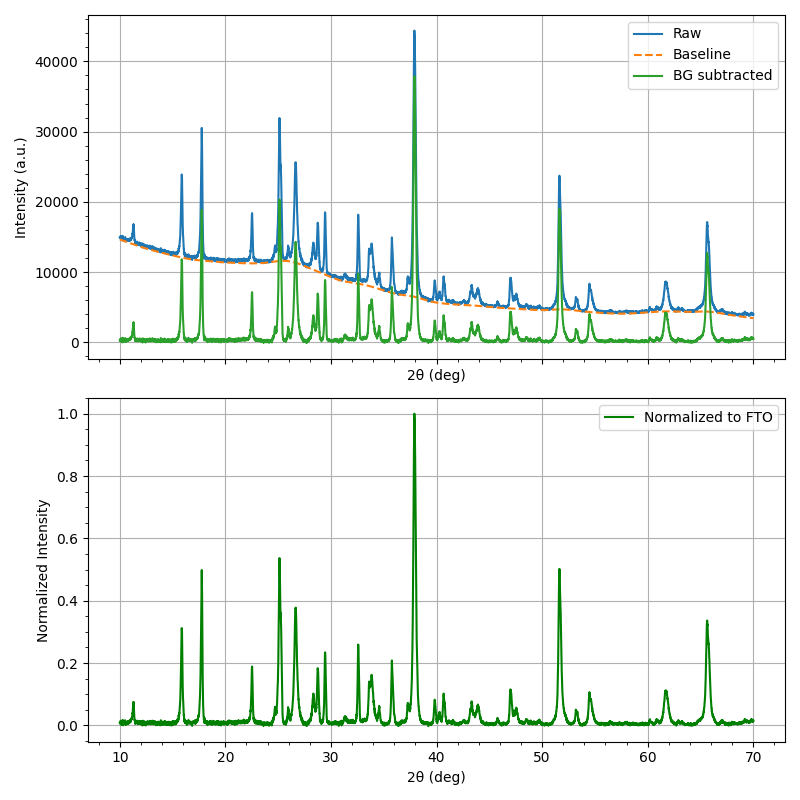

In [9]:
# Cell 5: Load, process, and plot
file_path = r"G:\My Drive\PhD\Research\Sb2S3 paper\XRD raw data\Sb2S3 data second batch of samples\10_25_07_0mM_baseline_Sb2S3.xy"
two_theta, intensity = load_XRD_txt(file_path)

# Background subtraction
baseline, corrected = subtract_background(intensity, lam=1e5, p=0.0001)

# Normalization to FTO peak at 37.9°
normalized_intensity = normalize_to_peak(two_theta, corrected, peak_center=37.9, window=0.2)

# Shift the spectrum to align the FTO peak at 37.9°
two_theta, shift = shift_spectrum_to_peak(two_theta, intensity, target_peak=37.9, window=0.4)
print(f"2θ shift applied: {shift:.4f} degrees")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), sharex=True)

# Top: raw and background-subtracted
ax1.plot(two_theta, intensity, label="Raw")
ax1.plot(two_theta, baseline, '--', label="Baseline")
ax1.plot(two_theta, corrected, label="BG subtracted")
ax1.set_xlabel("2θ (deg)")
ax1.set_ylabel("Intensity (a.u.)")
ax1.legend()
ax1.minorticks_on()
ax1.grid(True)

# Bottom: normalized_intensity
ax2.plot(two_theta, normalized_intensity, label="Normalized to FTO", color='green')
ax2.set_xlabel("2θ (deg)")
ax2.set_ylabel("Normalized Intensity")
ax2.legend()
ax2.minorticks_on()
ax2.grid(True)

plt.tight_layout()
plt.show()



In [15]:
# Cell 6: Save processed data

# Create the processed_data folder if it doesn't exist
output_folder = "processed_data"
os.makedirs(output_folder, exist_ok=True)

# Extract the base name of the input file (without extension)
input_file_name = os.path.basename(file_path)
output_file_name = os.path.splitext(input_file_name)[0] + "_processed.txt"

# Combine the folder and file name to create the full output path
output_file_path = os.path.join(output_folder, output_file_name)

# Save the raw data, baseline, corrected, normalized, and two_theta
processed_data = np.column_stack((two_theta, intensity, baseline, corrected, normalized_intensity))
np.savetxt(output_file_path, processed_data, 
           header="2theta\tintensity\tbaseline\tbg_subtracted\tnormalized", 
           fmt="%.5f")

print(f"Processed data saved to '{output_file_path}'")


Processed data saved to 'processed_data\10_25_07_0mM_baseline_Sb2S3_processed.txt'


In [16]:
# Cell 7: Define peaks and JCPDS intensities and define function to get peak intensity
# Format: 2theta (deg): relative intensity
peaks = {
    "020": (15.6, 57),
    "120": (17.5, 74),
    "220": (22.3, 27),
    "211": (29.2, 82),
    "221": (32.3, 66),
    "240": (35.5, 43)
}

def get_peak_intensity(two_theta, intensity, peak_pos, window=0.3):
    """
    Finds the nearest peak within a window around the given peak position,
    and returns the peak intensity and refined peak position.
    """
    # Mask the data within the specified window
    mask = (two_theta > peak_pos - window) & (two_theta < peak_pos + window)
    two_theta_window = two_theta[mask]
    intensity_window = intensity[mask]

    # Find peaks within the window
    peak_indices, _ = find_peaks(intensity_window)
    if len(peak_indices) == 0:
        raise ValueError(f"No peaks found near {peak_pos} within the window of ±{window}.")

    # Get the position of the highest peak in the window
    peak_index = peak_indices[np.argmax(intensity_window[peak_indices])]
    refined_peak_pos = two_theta_window[peak_index]
    peak_intensity = intensity_window[peak_index]

    return peak_intensity, refined_peak_pos


In [17]:
# Cell 8: Calculate Texture Coefficients (TCs)
# Texture coefficient formula:
# TC(hkl) = (I(hkl)/I0(hkl)) / ( (1/N) * sum(I(hkl)/I0(hkl)) )

I_over_I0 = []
measured_intensities = {}
refined_peak_positions = {}

for hkl, (pos, I0) in peaks.items():
    # Use the updated get_peak_intensity function
    peak_intensity, refined_pos = get_peak_intensity(two_theta, normalized_intensity, pos, window=0.3)
    measured_intensities[hkl] = peak_intensity
    refined_peak_positions[hkl] = refined_pos
    I_over_I0.append(peak_intensity / I0)

# Convert I_over_I0 to a NumPy array
I_over_I0 = np.array(I_over_I0)

# Calculate Texture Coefficients
TC_all = I_over_I0 / np.mean(I_over_I0)

# Map TCs to hkl
TC_dict = {hkl: TC_all[i] for i, hkl in enumerate(peaks.keys())}

# Print refined peak positions
print("Refined peak positions:")
for hkl, refined_pos in refined_peak_positions.items():
    print(f"{hkl}: {refined_pos:.2f}°")

# Print measured intensities
print("Measured peak intensities:")
for hkl, peak_intensity in measured_intensities.items():
    print(f"{hkl}: {peak_intensity:.2f}")

# Print Texture Coefficients
print("\nTexture Coefficients:")
for hkl in peaks.keys():
    print(f"TC({hkl}) = {TC_dict[hkl]:.5f}")

# Define the output file name
output_csv_file = "texture_coefficients.csv"

# Check if the file already exists
file_exists = os.path.isfile(output_csv_file)

# Open the file in append mode
with open(output_csv_file, mode="a", newline="") as file:
    writer = csv.writer(file)
    
    # Write the header only if the file does not exist
    if not file_exists:
        writer.writerow(["File"] + list(TC_dict.keys()))
    
    # Write the TC values for the current file
    writer.writerow([os.path.basename(file_path)] + [TC_dict[hkl] for hkl in TC_dict])

print(f"Texture coefficients appended to '{output_csv_file}'")

Refined peak positions:
020: 15.87°
120: 17.76°
220: 22.53°
211: 29.44°
221: 32.57°
240: 35.77°
Measured peak intensities:
020: 0.31
120: 0.50
220: 0.19
211: 0.23
221: 0.26
240: 0.21

Texture Coefficients:
TC(020) = 1.06564
TC(120) = 1.31037
TC(220) = 1.36033
TC(211) = 0.55633
TC(221) = 0.76491
TC(240) = 0.94242
Texture coefficients appended to 'texture_coefficients.csv'


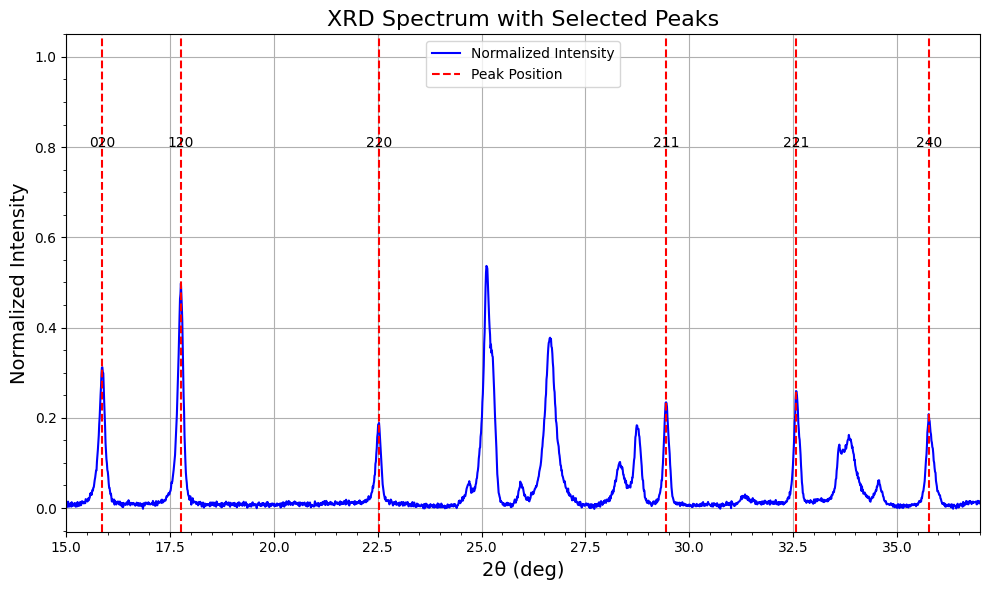

In [18]:
# Cell 9: Plot selected peaks
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the normalized intensity
ax.plot(two_theta, normalized_intensity, label="Normalized Intensity", color="blue")

# Highlight the peaks
for hkl, (pos, I0) in peaks.items():
    refined_pos = refined_peak_positions[hkl]
    # Mark the refined peak position
    ax.axvline(refined_pos, color="red", linestyle="--", label="Peak Position" if hkl == "020" else "")
    # Annotate the hkl label
    ax.text(refined_pos, normalized_intensity.max() * 0.8, hkl, color="black", fontsize=10, ha="center")

# Set axis limits dynamically
ax.set_xlim(15, 37)

# Add labels and legend
ax.set_xlabel("2θ (deg)", fontsize=14)
ax.set_ylabel("Normalized Intensity", fontsize=14)
ax.legend()
ax.minorticks_on()
ax.grid(True)

plt.title("XRD Spectrum with Selected Peaks", fontsize=16)
plt.tight_layout()
plt.show()